In [1]:
import xarray as xr
import numpy as np
import os, sys

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

In [2]:

# import dask
# from dask.distributed import LocalCluster, Client

# client = Client(LocalCluster(n_workers=4, threads_per_worker=2, memory_limit="8GB"))

In [3]:
# options

In [4]:
from glob import glob
import os

import xarray as xr
import zarr
from dask.distributed import wait

In [5]:
from dask.distributed import wait

In [6]:
import dask_gateway

gw = dask_gateway.Gateway("https://dask-gateway.jasmin.ac.uk", auth="jupyterhub")

options = gw.cluster_options()
options.account = "extant"
options.worker_cores = 1
options.worker_threads = 1

clusters = gw.list_clusters()
if not clusters:
    cluster = gw.new_cluster(options, shutdown_on_close=False)
else:
    cluster = gw.connect(clusters[0].name)

cluster.scale(20)
client = cluster.get_client()
client.wait_for_workers(8)

In [7]:
client#.close()

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /_jasmin/proxy/dask-gateway/clusters/d0d6e4a629024e53bde50404f434fc64/status,


# Opening and Processing Data

## ERA5

### Processing

Variable: tasmax
Processing steps
<br>
Temporal resulution:
- In: Sub-daily data
- Out: daily max

Spatial:
- In: full lat-lon
- Out: Between -90 and -60 latitude (just antarctica)

File type:
- In: netcf
- Out: zarr

Compression
- zstd
- Type change from float64 to float32


In [11]:
ERA5_ROOT = "/badc/ecmwf-era5/data/oper/an_sfc"
ZARR_OUT = "/work/scratch-pw4/aborow/era5_tasmax_antarctic.zarr"
YEARS = range(1979, 2025)

In [29]:
if os.path.exists(ZARR_OUT):
    YEARS = range(int(xr.open_zarr(ZARR_OUT).time.dt.year.max()) + 1, YEARS.stop)

In [33]:
YEARS

range(1979, 2025)

In [31]:
for year in YEARS:
    paths = sorted(glob(f"{ERA5_ROOT}/{year}/*/*/*.2t.nc"))
    print(f'{year=}, total files {len(paths)}')

    ds = (
        xr.open_mfdataset(
            paths,
            combine="nested",
            concat_dim="time",
            parallel=True,
            data_vars="minimal",
            coords="minimal",
            compat="override",
            preprocess=lambda d: d.sortby('latitude').sel(latitude=slice(-90.0, -60.0)),
        )["t2m"]
        .resample(time="1D")
        .max()
        .rename("tasmax")
        .to_dataset()
    )
    ds["tasmax"] = ds["tasmax"].astype("float32")
    ds["tasmax"].encoding = {}
    ds = ds.load()

    if os.path.exists(ZARR_OUT):
        ds.to_zarr(ZARR_OUT, append_dim="time", align_chunks=True)
    else:
        ds.to_zarr(ZARR_OUT, mode="w", encoding={"tasmax": {"chunks": (365, 121, 120)}})
    print(year, flush=True)

year=1979, total files 8760


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 34.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


1979


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


year=1980, total files 8784


...

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


year=2024, total files 8784


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 34.58 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


2024


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [32]:
ds

<xarray.Dataset> Size: 255MB
Dimensions:    (longitude: 1440, latitude: 121, time: 366)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 484B -90.0 -89.75 -89.5 ... -60.5 -60.25 -60.0
  * time       (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
Data variables:
    tasmax     (time, latitude, longitude) float32 255MB 249.2 249.2 ... 272.8

In [34]:
TARGET_CHUNKS = {"time": -1, "latitude": 20, "longitude": 40}

In [35]:
da = xr.open_zarr(ZARR_OUT).tasmax.astype("float32").chunk(TARGET_CHUNKS)

In [37]:
da

<xarray.DataArray 'tasmax' (time: 16802, latitude: 121, longitude: 1440)> Size: 12GB
dask.array<rechunk-p2p, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 484B -90.0 -89.75 -89.5 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

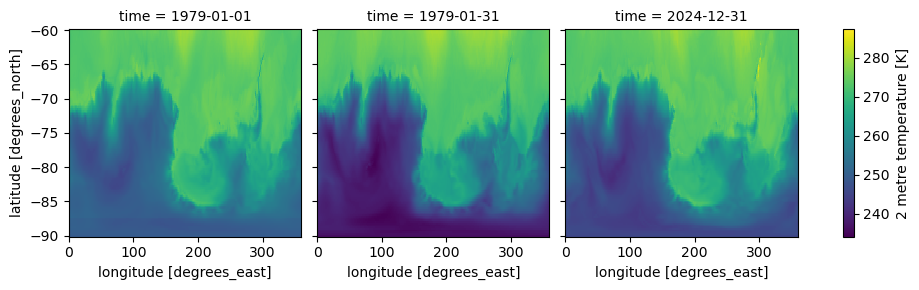

In [38]:
da.isel(time=[0, 30, -1]).sel(latitude=slice(None, -60)).plot(col='time')

In [39]:
da#.sel(latitude=slice(-90, -60))

<xarray.DataArray 'tasmax' (time: 16802, latitude: 121, longitude: 1440)> Size: 12GB
dask.array<rechunk-p2p, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 484B -90.0 -89.75 -89.5 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

In [40]:
da = da.rename({'latitude': 'lat', 'longitude': 'lon'})

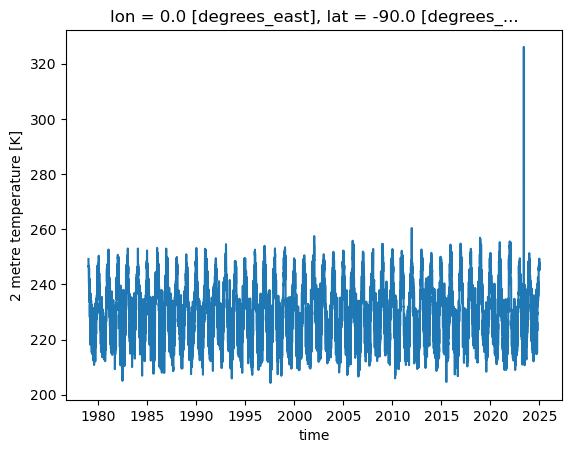

In [43]:
da.isel(lat=0, lon=0).plot()

In [44]:
from zarr.codecs import BloscCodec, BloscShuffle

compressor = BloscCodec(cname="zstd", clevel=5, shuffle=BloscShuffle.bitshuffle)

encoding = {
    "tasmax": {
        "compressors": [compressor],
        "chunks": (da.sizes["time"], 20, 40),
    }
}

In [45]:
ZARR_OUT_2 = '/work/scratch-pw4/aborow/era5_tasmax_antarctic_v2.zarr'

'/work/scratch-pw4/aborow/era5_tasmax_antarctic_v2.zarr'

In [47]:
da.to_dataset(name="tasmax").to_zarr(
    ZARR_OUT_2,
    encoding=encoding,
    consolidated=True,
    mode="w",
)

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [48]:
da

<xarray.DataArray 'tasmax' (time: 16802, lat: 121, lon: 1440)> Size: 12GB
dask.array<rechunk-p2p, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

### Opening

In [8]:
ZARR_OUT_2 = '/work/scratch-pw4/aborow/era5_tasmax_antarctic_v2.zarr'

In [9]:
era5_da = xr.open_zarr(ZARR_OUT_2).tasmax

In [10]:
era5_da

<xarray.DataArray 'tasmax' (time: 16802, lat: 121, lon: 1440)> Size: 12GB
dask.array<open_dataset-tasmax, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

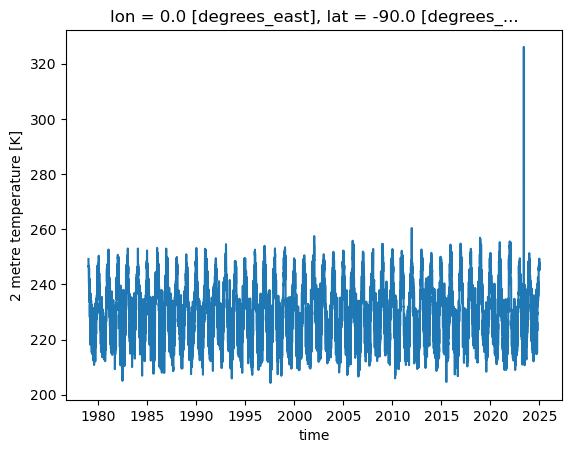

In [11]:
era5_da.isel(lat=0, lon=0).plot()

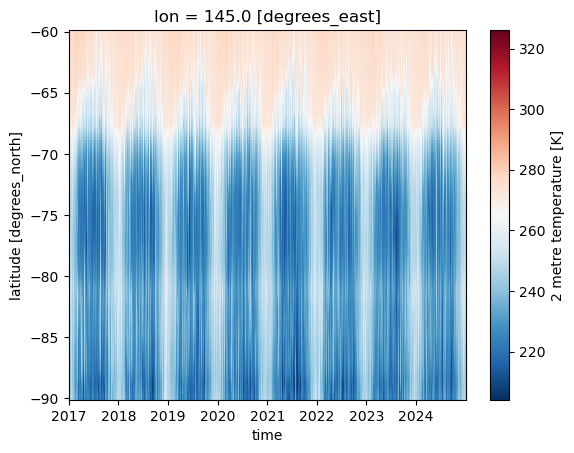

In [12]:
era5_da.sel(lat=slice(-90, -60)).sel(lon=145, method='nearest').sel(time=era5_da.time.dt.year>2016).plot(x='time', cmap='RdBu_r');

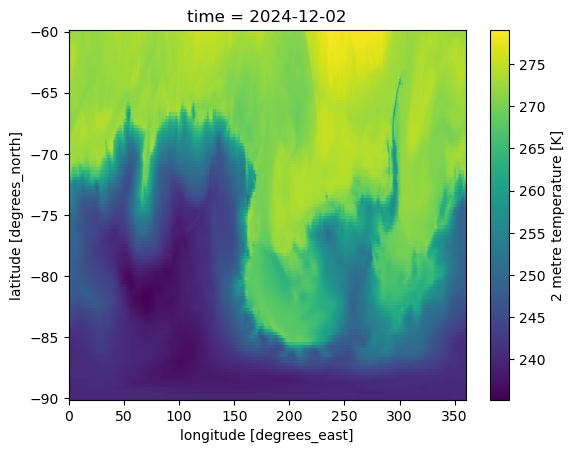

In [13]:
era5_da.isel(time=-30).plot()

## LESFMIP

In [14]:
# tasmax_day_HadGEM3-GC31-LL_hist-GHG_r1i1p1f3_gn_18500101-19491230.nc  tasmax_day_HadGEM3-GC31-LL_hist-GHG_r1i1p1f3_gn_19500101-20201230.nc
# tasmax_day_HadGEM3-GC31-LL_hist-GHG_r1i1p1f3_gn_18500101-19491230.nc  tasmax_day_HadGEM3-GC31-LL_hist-GHG_r1i1p1f3_gn_19500101-20201230.nc

In [15]:
os.listdir('/gws/nopw/j04')

['swift_s2stest',
 'parachute',
 'smbgen2',
 'ramip',
 'ew4energy',
 'acacia',
 'openclim',
 'mohc_shared',
 'acure',
 'nzplus',
 'mu_mip',
 'quasar',
 'ncas_generic',
 'acsis',
 'wcssp_india',
 'cranews1',
 'kscale',
 'scenario']

In [16]:
ROOT_DIR = '/gws/ssde/j25a/extant/data'

In [17]:
potential_models = np.array(os.listdir(ROOT_DIR))
models = np.array([m for m in potential_models if os.path.isdir(os.path.join(ROOT_DIR, m))])
models

array(['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'BCC-ESM1', 'CESM2',
       'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM2', 'CanESM5',
       'E3SM-1-0', 'EC-Earth3-Veg', 'EC-Earth3', 'ERA5', 'FGOALS-g3',
       'GISS-E2-1-G', 'HadGEM3-GC31-CANARI', 'HadGEM3-GC31-LL',
       'HadGEM3-GC31-MM', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L',
       'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3',
       'NorESM2-LM', 'RCM', 'UKESM1-0-LL', 'downloading'], dtype='<U19')

In [18]:
LESMIP_MODELS = ['ACCESS-ESM1-5',
       'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CanESM5',
       'GISS-E2-1-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR',
       'MIROC6', 'MPI-ESM1-2-LR',
       'NorESM2-LM']

In [19]:
len(LESMIP_MODELS)

10

In [20]:
from glob import glob

In [21]:
from collections import defaultdict
from pprint import pprint

In [22]:
# nested = lambda: defaultdict(nested)
# model_list_dict = nested()
# model_list_dict

In [23]:
model_list_dict = defaultdict(dict)


for model in LESMIP_MODELS:
    print(model)
    model_path = os.path.join(ROOT_DIR, model, 'day')
    variables = os.listdir(model_path)
    for variable in variables:
        # print(variable)
        variable_path = os.path.join(model_path, variable)
        if os.path.isdir(variable_path): 
            glob_path = os.path.join(variable_path, '**', '*.nc')
            print(f'searching {glob_path}')
            full_paths = glob(glob_path, recursive=True)
            fnames = full_paths#list(map(os.path.basename, full_paths))
            fnames_grouped = defaultdict(list)
            for fname in fnames:
                fnames_grouped[fname.split('_')[3]].append(fname)

            model_list_dict[model][variable] = {'path': variable_path, 'fnames': fnames_grouped}

ACCESS-ESM1-5
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/pr/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/psl/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/va/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/vas/**/*.nc
CMCC-CM2-SR5
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/pr/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/va/**/*.nc
CNRM-CM6-1
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/psl/**/*.nc
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/

In [24]:
model_list_dict

defaultdict(dict,
            {'ACCESS-ESM1-5': {'pr': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/pr',
               'fnames': defaultdict(list, {})},
              'psl': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/psl',
               'fnames': defaultdict(list, {})},
              'tas': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tas',
               'fnames': defaultdict(list, {})},
              'tasmax': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax',
               'fnames': defaultdict(list, {})},
              'uas': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas',
               'fnames': defaultdict(list,
                           {'historical': ['/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/uas_day_ACCESS-ESM1-5_historical_r10i1p1f1_gn_19500101-19991231.nc',
                             '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/uas_day_ACCESS-ESM1-5_historical_r10i1p1f1_gn_20000101-20141231.nc',
  

In [25]:
{model: values.get('tasmax') for model, values in model_list_dict.items()}

{'ACCESS-ESM1-5': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CMCC-CM2-SR5': {'path': '/gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CNRM-CM6-1': {'path': '/gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CanESM5': {'path': '/gws/ssde/j25a/extant/data/CanESM5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'GISS-E2-1-G': {'path': '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax',
  'fnames': defaultdict(list,
              {'hist-sol': ['/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_18500101-18991231.nc',
                '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_19000101-19391231.nc',
                '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_19400101-19791231.nc',
                '/gws/ssde

In [26]:
model = 'HadGEM3-GC31-LL'

In [27]:
sample_dict = model_list_dict[model]['tasmax']

In [28]:
sample_dict.keys()

dict_keys(['path', 'fnames'])

In [29]:
sample_dict['fnames'].keys()

dict_keys(['hist-GHG', 'hist-aer', 'hist-lu', 'hist-nat', 'hist-sol', 'hist-totalO3', 'hist-volc', 'historical', 'day'])

In [30]:
hist_path = sample_dict['fnames']['historical'][0]
hist_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_18500101-19491230.nc'

In [31]:
hist_path_split = os.path.basename(hist_path).split('.')[0].split('_')
experiment, ensemble_member, _, time = hist_path_split[-4:]
experiment, ensemble_member, _, time

('historical', 'r11i1p1f3', 'gn', '18500101-19491230')

In [32]:
hist_match = [f for f in sample_dict['fnames']['historical'] if ((experiment in f) and (ensemble_member in f))]
hist_match

['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_18500101-19491230.nc',
 '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_19500101-20141230.nc']

In [33]:
import re

In [34]:
hist_wild_path = re.sub(r'_gn_\d+-\d+\.nc$', '_gn_*.nc', hist_match[0])
hist_wild_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_*.nc'

In [35]:
# hist_da = xr.open_mfdataset(hist_wild_path)

In [36]:
ensmemble_date_str = "_".join(hist_path.split('.')[0].split('_')[-3:])
ensmemble_date_str

'r11i1p1f3_gn_18500101-19491230'

In [37]:
hist_nat_path = sample_dict['fnames']['hist-nat'][0]
hist_nat_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_r10i1p1f3_gn_18500101-19491230.nc'

In [38]:
hist_nat_wild_path = re.sub(r'_gn_\d+-\d+.nc$', '_gn_*.nc',hist_nat_path)
hist_nat_wild_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_r10i1p1f3_gn_*.nc'

In [39]:
hist_ds = xr.open_mfdataset(
    hist_wild_path,
    chunks={'time': 3650, 'lat': -1, 'lon': -1},
    parallel=True,
).sel(lat=slice(-90, -60)).tasmax

In [52]:
hist_nat_ds = xr.open_mfdataset(
    hist_nat_path,
    chunks={'time': 3650, 'lat': -1, 'lon': -1},
    parallel=True,
).sel(lat=slice(-90, -60)).chunk({'time': -1, 'lat': -1, 'lon': -1}).tasmax

In [143]:
hist_ds

<xarray.DataArray 'tasmax' (time: 59400, lat: 24, lon: 192)> Size: 1GB
dask.array<where, shape=(59400, 24, 192), dtype=float32, chunksize=(3650, 24, 192), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 475kB 1850-01-01 12:00:00 ... 2014-12-30 12:00:00
  * lat      (lat) float64 192B -89.38 -88.12 -86.88 ... -63.12 -61.88 -60.62
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B 1.5
    type     |S4 4B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    comment:        maximum near-surface (usually, 2 meter) air temperature (...
    units:          K
    original_name:  mo: (stash: m01s03i236, lbproc: 8192)
    cell_methods:   area: mean time: maximum
    cell_measures:  area: areacella
    history:        2023-05-16T18:37:57Z altered by CMOR: Treated scalar dime...

In [45]:
LANDSEA_DIR = '/badc/cmip6/data/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/fx/sftlf/gn/latest/'

In [46]:
os.listdir(LANDSEA_DIR)

['sftlf_fx_HadGEM3-GC31-LL_piControl_r1i1p1f1_gn.nc']

In [50]:
landsea_mask_ds = xr.open_dataset(os.path.join(LANDSEA_DIR, 'sftlf_fx_HadGEM3-GC31-LL_piControl_r1i1p1f1_gn.nc')).sftlf
landsea_mask_ds

<xarray.DataArray 'sftlf' (lat: 144, lon: 192)> Size: 111kB
[27648 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    type     |S4 4B ...
Attributes:
    standard_name:   land_area_fraction
    long_name:       Percentage of the grid  cell occupied by land (including...
    comment:         Please express 'X_area_fraction' as the percentage of ho...
    units:           %
    original_name:   mo: (stash: m01s00i505)
    original_units:  1
    history:         2019-07-08T15:34:25Z altered by CMOR: Converted units fr...
    cell_methods:    area: mean
    cell_measures:   area: areacella

In [57]:
hist_nat_ds = hist_nat_ds.where(landsea_mask_ds)#.isel(time=-1).plot()
hist_ds = hist_ds.where(landsea_mask_ds)

# Trends and S/N Ratio

## Functions

In [40]:
from matplotlib.gridspec import GridSpec

In [41]:
def grid_slope(da, dim='time'):
    """Per-cell OLS slope of y = a + b*x.

    Closed-form normal-equation solution:

        b   = Sxy / Sxx
        Sxx = sum((x - xbar)^2)          spread of the time axis
        Sxy = sum((x - xbar)(y - ybar))  covariation of y with time

    Vectorised over all non-`dim` dimensions, so no per-cell loop.
    Time is converted to float years, since cftime objects don't support
    the arithmetic. Assumes one value per year — sub-annual data collapses
    Sxx, as every point within a year shares the same x.

    Parameters
    ----------
    da : xr.DataArray
        Input with cftime/datetime `dim`; other dims treated as cells.
    dim : str
        Dimension to regress along.

    Returns
    -------
    xr.DataArray
        Slope of the data.
    """
    x = xr.DataArray(np.arange(da.sizes[dim], dtype=float), dims=dim)

    dx = x - x.mean(dim)
    slope = (dx * (da - da.mean(dim))).sum(dim) / (dx ** 2).sum(dim)
    # slope.attrs['units'] = f"{da.attrs.get('units', '')} yr-1".strip()
    return slope

In [42]:
import numpy as np
import xarray as xr
from scipy.stats import norm


def mk_S(y, i, j):
    """Mann-Kendall S statistic along the last axis.

    S = sum_{k<l} sign(y_l - y_k), as a broadcast pairwise difference
    over precomputed upper-triangle index pairs.

    Parameters
    ----------
    y : np.ndarray
        Shape (..., n); leading axes treated as independent cells.
    i, j : np.ndarray
        Upper-triangle index pairs from np.triu_indices(n, k=1).

    Returns
    -------
    np.ndarray
        S with shape y.shape[:-1].
    """
    return np.sign(y[..., j] - y[..., i]).sum(axis=-1)


def grid_mk(da, dim='time', alpha=0.05):
    """Per-cell Mann-Kendall test, lazy over dask.

        Var(S) = n(n-1)(2n+5) / 18          no-ties form
        Z      = (S -/+ 1) / sqrt(Var)      continuity-corrected, 0 if S = 0
        p      = 2 * P(N(0,1) > |Z|)

    apply_ufunc moves `dim` to the last axis, which is what mk_S expects.

    Parameters
    ----------
    da : xr.DataArray
        Input; `dim` is the time axis, other dims treated as cells.
    dim : str
        Dimension to test along.
    alpha : float
        Threshold for the significance mask.

    Returns
    -------
    xr.Dataset
        S, Z, p (two-sided), sig (bool, p < alpha).
    """
    n = da.sizes[dim]
    i, j = np.triu_indices(n, k=1)
    var = n * (n - 1) * (2 * n + 5) / 18.0

    S = xr.apply_ufunc(
        lambda y: mk_S(y, i, j),
        da,
        input_core_dims=[[dim]],
        dask='parallelized', output_dtypes=[float]
        )

    Z = xr.where(S > 0, (S - 1) / np.sqrt(var),
        xr.where(S < 0, (S + 1) / np.sqrt(var), 0.0))
    p = xr.apply_ufunc(lambda z: 2 * norm.sf(np.abs(z)), Z,
                       dask='parallelized', output_dtypes=[float])

    return xr.Dataset({'S': S, 'Z': Z, 'p': p, 'sig': p < alpha})

In [43]:
def grid_intercept(da, slope, dim='time'):
    """Per-cell OLS intercept of y = a + b*x, given b.

        a = ybar - b * xbar

    Uses the same x as `grid_slope`: 0, 1, ..., n-1 along `dim`. The
    intercept is therefore the fitted value at the *first* time step,
    not at any calendar epoch.

    Parameters
    ----------
    da : xr.DataArray
        Input with cftime/datetime `dim`; other dims treated as cells.
    slope : xr.DataArray
        Slope from `grid_slope(da, dim)`, broadcastable against `da`
        over the non-`dim` dims.
    dim : str
        Dimension the regression was taken along.

    Returns
    -------
    xr.DataArray
        Intercept of the data.
    """
    x = xr.DataArray(np.arange(da.sizes[dim], dtype=float), dims=dim)
    return da.mean(dim) - slope * x.mean(dim)

## Calculations

In [44]:
era5_da

<xarray.DataArray 'tasmax' (time: 16802, lat: 121, lon: 1440)> Size: 12GB
dask.array<open_dataset-tasmax, shape=(16802, 121, 1440), dtype=float32, chunksize=(16802, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * time     (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
Attributes:
    units:      K
    long_name:  2 metre temperature

In [45]:
era5_seasonal_da = era5_da.resample(time='QS-DEC').max().persist()
wait(era5_seasonal_da);

In [46]:
era5_seasonal_da

<xarray.DataArray 'tasmax' (time: 185, lat: 121, lon: 1440)> Size: 129MB
dask.array<transpose, shape=(185, 121, 1440), dtype=float32, chunksize=(185, 20, 40), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
  * time     (time) datetime64[ns] 1kB 1978-12-01 1979-03-01 ... 2024-12-01
Attributes:
    units:      K
    long_name:  2 metre temperature

In [47]:
era5_spring_da = era5_seasonal_da.sel(time=era5_seasonal_da['time.month']==9)
era5_spring_g2000_da = era5_spring_da.sel(time=era5_spring_da['time.year'] > 2000)

era5_spring_slope_g2000_da = grid_slope(era5_spring_g2000_da).compute()
era5_spring_yint_g2000_da = grid_intercept(era5_spring_g2000_da, era5_spring_slope_g2000_da).compute()

era5_spring_trend_g2000_da = era5_spring_slope_g2000_da * xr.DataArray(
    np.arange(era5_spring_g2000_da['time'].shape[0], dtype=float), dims='time') + era5_spring_yint_g2000_da
era5_spring_trend_g2000_da['time'] = era5_spring_g2000_da.time.values

era5_spring_g2000_da_detrend = era5_spring_g2000_da - era5_spring_trend_g2000_da

era5_spring_g2000_noise_da = era5_spring_g2000_da_detrend.std(dim='time').compute();

era5_spring_g2000_signal_da = era5_spring_slope_g2000_da * xr.DataArray((np.arange(era5_spring_g2000_da.sizes['time'], dtype=float)), dims='time',coords={'time': era5_spring_g2000_da.time})

era5_spring_g2000_sn_da = era5_spring_g2000_signal_da/era5_spring_g2000_noise_da
era5_spring_g2000_sn_da = era5_spring_g2000_sn_da.compute()

era5_spring_g2000_sn_da

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 31.98 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray (lat: 121, lon: 1440, time: 24)> Size: 33MB
array([[[0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        ...,
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756],
        [0.        , 0.02331424, 0.04662848, ..., 0.48959907,
         0.51291331, 0.53622756]],

       [[0.        , 0.02832236, 0.05664472, ..., 0.59476956,
         0.62309192, 0.65141428],
        [0.        , 0.02829736, 0.05659471, ..., 0.59424446,
         0.62254181, 0.65083917],
        [0.        , 0.02824471, 0.05648943, ..., 0.59313897,
         0.62138368, 0.6496284 ],
...
        [0.        , 0.02277466, 0.04554932, ..., 0.47826788,
         0.50104254, 0.5238172 ],
        [0.        , 0.02249601, 0.04499202, ..., 0.47241618,
         0.49491219, 0.5174082 ],
        [0.        , 0.02118609, 0.04237218, ..., 0.44490794,
         0.46609403, 0.48728012]],

       [[0.        , 0.02179096, 0.04358193, ..., 0.45761023,
         0.4794012 , 0.50119216],
        [0.        , 0.0207316 , 0.0414632 , ..., 0.43536356,
         0.45609516, 0.47682676],
        [0.        , 0.02086936, 0.04173873, ..., 0.43825663,
         0.459126  , 0.47999536],
        ...,
        [0.        , 0.02192756, 0.04385513, ..., 0.46047886,
         0.48240642, 0.50433399],
        [0.        , 0.02287981, 0.04575963, ..., 0.48047611,
         0.50335593, 0.52623574],
        [0.        , 0.02200581, 0.04401162, ..., 0.462122  ,
         0.48412781, 0.50613362]]], shape=(121, 1440, 24))
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
  * time     (time) datetime64[ns] 192B 2001-09-01 2002-09-01 ... 2024-09-01

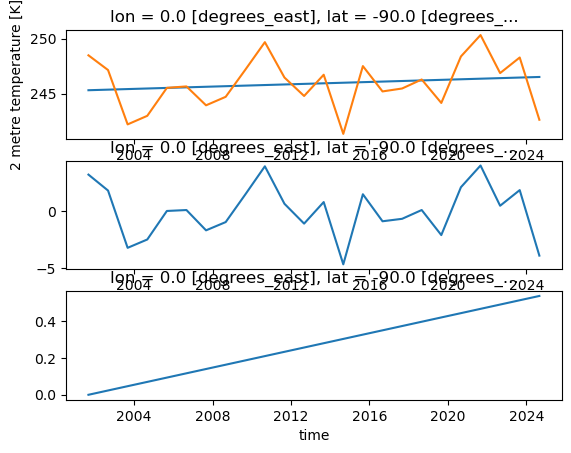

In [48]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
era5_spring_trend_g2000_da.isel(lat=0, lon=0).plot(ax=ax1)
era5_spring_g2000_da.isel(lat=0, lon=0).plot(ax=ax1)
era5_spring_g2000_da_detrend.isel(lat=0, lon=0).plot(ax=ax2)
era5_spring_g2000_sn_da.isel(lat=0, lon=0).plot(ax=ax3)

## Plotting

Text(0.5, 0.975, 'ERA5 spring (SON) maximum SAT, 2000 onwards')

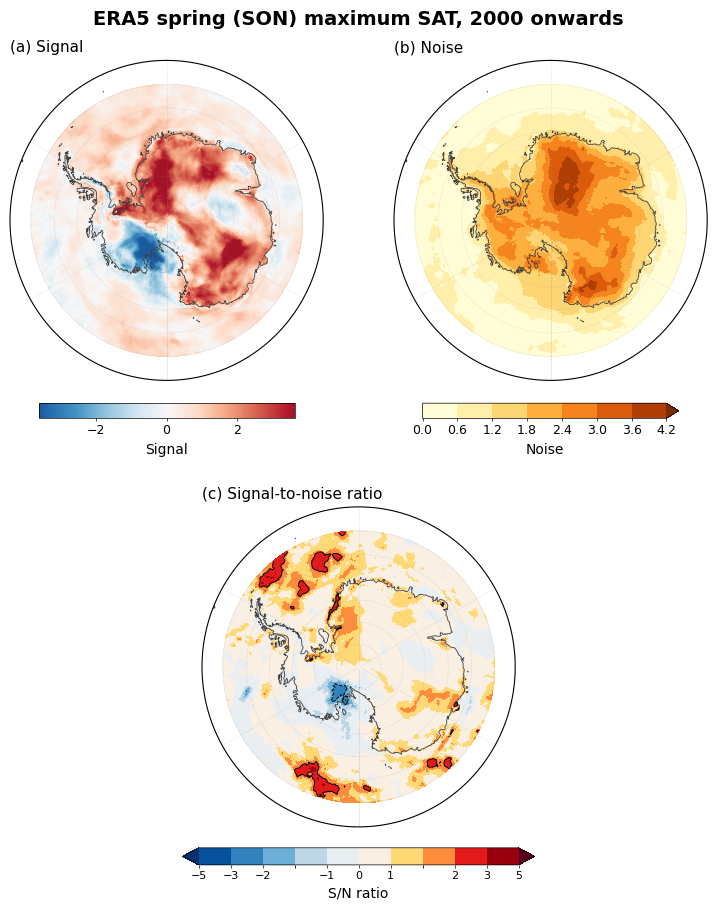

In [49]:
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.path as mpath


def truncate_cmap(name, lo=0.0, hi=1.0, n=256):
    base = mpl.colormaps[name]
    return mcolors.LinearSegmentedColormap.from_list(
        f'{name}_{lo}_{hi}', base(np.linspace(lo, hi, n)))


SIG_CMAP = truncate_cmap('RdBu_r', 0.08, 0.92)
NOISE_CMAP = truncate_cmap('YlOrBr', 0.05, 0.95)

# 9 bins: 4 negative (blue), 1 central "below noise" (grey), 4 positive (yellow->red)
SN_LEVELS = [-5, -3, -2, -1.5, -1, 0, 1, 1.5, 2, 3, 5]
SN_TICKS = [-5, -3, -2, -1, 0, 1, 2, 3, 5]
SN_CMAP = mcolors.ListedColormap(
    ['#08519c', '#3182bd', '#6baed6', '#bdd7e7',
     '#e8eef2', '#f9efe2',
     '#fed976', '#fd8d3c', '#e31a1c', '#99000d'])
SN_CMAP.set_under('#08306b')
SN_CMAP.set_over('#54001a')
SN_NORM = mcolors.BoundaryNorm(SN_LEVELS, SN_CMAP.N)

UNIVERSAL_PLOT_KWARGS = dict(transform=ccrs.PlateCarree(), add_labels=False,
                             add_colorbar=False)

# --- figure and axes (explicit positions, figure coordinates) ---
fig = plt.figure(figsize=(8, 9.5))

MAP_W = 0.40
MAP_H = MAP_W * 8 / 9.5   # square in inches

ax_a = fig.add_axes([0.06, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())
ax_b = fig.add_axes([0.54, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())
ax_c = fig.add_axes([0.30, 0.115, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())

cax_a = fig.add_axes([0.10, 0.545, 0.32, 0.016])
cax_b = fig.add_axes([0.58, 0.545, 0.32, 0.016])
cax_c = fig.add_axes([0.28, 0.075, 0.44, 0.018])

# --- data ---
p_a = era5_spring_g2000_signal_da.isel(time=-1).plot(
    ax=ax_a, robust=True, cmap=SIG_CMAP, **UNIVERSAL_PLOT_KWARGS)
p_b = era5_spring_g2000_noise_da.plot(
    ax=ax_b, robust=True, levels=7, cmap=NOISE_CMAP, extend='max',
    **UNIVERSAL_PLOT_KWARGS)
p_c = era5_spring_g2000_sn_da.isel(time=-1).plot(
    ax=ax_c, cmap=SN_CMAP, norm=SN_NORM, **UNIVERSAL_PLOT_KWARGS)

era5_spring_g2000_sn_da.isel(time=-1).plot.contour(
    ax=ax_c, levels=[-2, 2], colors='k', linewidths=0.7, add_labels=False,
    transform=ccrs.PlateCarree())

# --- colorbars ---
cb_a = fig.colorbar(p_a, cax=cax_a, orientation='horizontal', label='Signal')
cb_b = fig.colorbar(p_b, cax=cax_b, orientation='horizontal', label='Noise')
cb_c = fig.colorbar(p_c, cax=cax_c, orientation='horizontal', label='S/N ratio',
                    extend='both', ticks=SN_TICKS, spacing='uniform')

for cb in (cb_a, cb_b, cb_c):
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=9, length=2, width=0.5, pad=2)
    cb.ax.xaxis.label.set_size(10)

cb_c.ax.tick_params(labelsize=8)
cb_c.dividers.set_color('white')
cb_c.dividers.set_linewidth(0.8)

# --- map furniture ---
theta = np.linspace(0, 2 * np.pi, 200)
circle = mpath.Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)

for ax in (ax_a, ax_b, ax_c):
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.6, color='0.25')
    ax.gridlines(linewidth=0.4, color='0.6', alpha=0.5, linestyle=':')

ax_a.set_title('(a) Signal', loc='left', fontsize=11)
ax_b.set_title('(b) Noise', loc='left', fontsize=11)
ax_c.set_title('(c) Signal-to-noise ratio', loc='left', fontsize=11)

fig.suptitle('ERA5 spring (SON) maximum SAT, 2000 onwards', fontsize=14, fontweight='bold', y=0.975)

In [51]:
# era5_spring_slope_da = grid_slope(era5_seasonal_da).compute()

In [52]:
def max_locations(ds, number:int=10, ascending=True) -> list:
    ds = ds.stack(latlon=['lat', 'lon'])
    ds = ds.sortby(ds, ascending=ascending)
    latlon_largest = ds.isel(latlon=slice(0, number)).latlon.values
    latlon_largest_formatted = [{'lat': latlon[0], 'lon': latlon[1]} for latlon in latlon_largest]
    return  latlon_largest_formatted

In [53]:
latlon_largest_era5_seasonal = max_locations(era5_spring_slope_g2000_da, ascending=False)
latlon_largest_era5_seasonal

[{'lat': -74.0, 'lon': 112.25},
 {'lat': -73.75, 'lon': 112.0},
 {'lat': -74.0, 'lon': 112.0},
 {'lat': -74.0, 'lon': 112.5},
 {'lat': -73.75, 'lon': 112.25},
 {'lat': -73.75, 'lon': 111.75},
 {'lat': -74.25, 'lon': 112.75},
 {'lat': -74.25, 'lon': 112.5},
 {'lat': -74.25, 'lon': 112.25},
 {'lat': -74.0, 'lon': 111.75}]

In [59]:
latlon_largest_era5_seasonal_sn = max_locations(era5_spring_g2000_sn_da.isel(time=-1), ascending=False)
latlon_largest_era5_seasonal_sn

[{'lat': -65.0, 'lon': 203.75},
 {'lat': -65.0, 'lon': 203.5},
 {'lat': -65.0, 'lon': 204.0},
 {'lat': -65.25, 'lon': 203.75},
 {'lat': -65.0, 'lon': 203.25},
 {'lat': -65.25, 'lon': 203.5},
 {'lat': -65.0, 'lon': 204.25},
 {'lat': -65.25, 'lon': 204.0},
 {'lat': -65.25, 'lon': 203.25},
 {'lat': -65.0, 'lon': 203.0}]

In [60]:
import matplotlib.pyplot as plt


def make_axes(fig, npanels, layout="col", height_ratios=(5, 1)):
    axes, tab_axes = [], []
    if layout == "col":
        gs = fig.add_gridspec(2, npanels, height_ratios=height_ratios)
        slots = [(gs[0, i], gs[1, i]) for i in range(npanels)]
    elif layout == "row":
        gs = fig.add_gridspec(2 * npanels, 1,
                              height_ratios=list(height_ratios) * npanels)
        slots = [(gs[2 * i, 0], gs[2 * i + 1, 0]) for i in range(npanels)]
    else:
        raise ValueError("layout must be 'col' or 'row'")

    for plot_slot, tab_slot in slots:
        axes.append(fig.add_subplot(plot_slot, sharex=axes[0] if axes else None))
        tab_axes.append(fig.add_subplot(tab_slot))
    return axes, tab_axes


def plot_signal_sn(points, left_key, right_key, table_keys,
                   layout="col", figsize=None, height_ratios=(5, 1),
                   left_color="tab:blue", right_color="tab:red",
                   left_label="Temperature (K)"):
    n = len(points)
    if figsize is None:
        figsize = (6 * n, 5) if layout == "col" else (7, 3.5 * n)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    axes, tab_axes = make_axes(fig, n, layout, height_ratios)

    for ax, ax_tab, p in zip(axes, tab_axes, points):
        draw_panel(ax, p["label"], p["pt"], p["data"], left_key, right_key,
                   left_color=left_color, right_color=right_color,
                   left_label=left_label)
        draw_table(ax_tab, p["data"], table_keys)

    return fig, axes

In [61]:
def draw_panel(ax, label, pt, data, left_key, right_key,
               left_color="tab:blue", right_color="tab:red",
               left_label="Temperature (K)"):
    left, right = data[left_key], data[right_key]

    l1, = ax.plot(left.time, left, color=left_color, lw=1.2,
                  label=f"{left_key} ({endpoint(left):.2f})")
    ax.set_ylabel(left_label, color=left_color)
    ax.tick_params(axis="y", labelcolor=left_color, length=3)
    ax.tick_params(axis="x", length=3)
    ax.set_title(f"{label}: {pt['lat']}°, {pt['lon']}°", fontsize=11, pad=8)
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)

    ax2 = ax.twinx()
    l2, = ax2.plot(right.time, right, color=right_color, lw=1.8,
                   label=f"{right_key} ({endpoint(right):.2f})")
    ax2.set_ylabel(right_key, color=right_color)
    ax2.tick_params(axis="y", labelcolor=right_color, length=3)
    ax2.axhline(0, color="0.5", lw=0.8, ls=":")

    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax.legend(handles=[l1, l2], loc="upper left", frameon=False, fontsize=12)
    return ax2

In [69]:
def draw_table(ax, data, table_keys):
    ax.axis("off")
    tab = ax.table(cellText=[[f"{endpoint(data[k]):.2f}" for k in table_keys]],
                   colLabels=list(table_keys),
                   cellLoc="center", loc="center")
    tab.auto_set_font_size(False)
    tab.set_fontsize(9)
    tab.scale(1, 1.3)
    for (r, c), cell in tab.get_celld().items():
        cell.set_edgecolor("0.8")
        if r == 0:
            cell.set_text_props(weight="bold")
    return tab

In [70]:
def extract_point(label, pt, arrays):
    sel = dict(lat=pt["lat"], lon=pt["lon"], method="nearest")
    return {"label": label,
            "pt": pt,
            "data": {name: da.sel(**sel) for name, da in arrays.items()}}

def endpoint(da):
    return da.isel(time=-1).values if "time" in da.dims else da.values

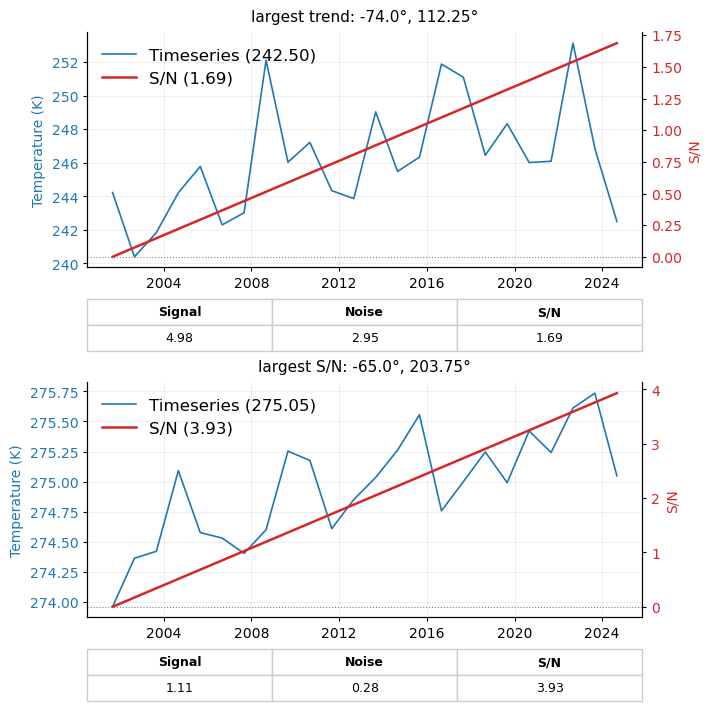

In [71]:
arrays = {
    "Timeseries": era5_spring_g2000_da,
    "Signal": era5_spring_g2000_signal_da,
    "Noise": era5_spring_g2000_noise_da,
    "S/N": era5_spring_g2000_sn_da,
}

fig, axes = plot_signal_sn(
    points=[extract_point("largest trend", latlon_largest_era5_seasonal[0], arrays),
            extract_point("largest S/N", latlon_largest_era5_seasonal_sn[0], arrays)],
    left_key="Timeseries",
    right_key="S/N",
    table_keys=["Signal", "Noise", "S/N"],
    layout="row",
)

## Hist Nat

In [72]:
hist_seasonal_ds = hist_ds.resample(time='QS-DEC').max()
hist_seasonal_ds

<xarray.DataArray 'tasmax' (time: 661, lat: 24, lon: 192)> Size: 12MB
dask.array<transpose, shape=(661, 24, 192), dtype=float32, chunksize=(81, 24, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 192B -89.38 -88.12 -86.88 ... -63.12 -61.88 -60.62
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B 1.5
  * time     (time) object 5kB 1849-12-01 00:00:00 ... 2014-12-01 00:00:00
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    comment:        maximum near-surface (usually, 2 meter) air temperature (...
    units:          K
    original_name:  mo: (stash: m01s03i236, lbproc: 8192)
    cell_methods:   area: mean time: maximum
    cell_measures:  area: areacella
    history:        2023-05-16T18:37:57Z altered by CMOR: Treated scalar dime...

In [73]:
hist_seasonal_match_ds = hist_seasonal_ds.where(hist_seasonal_ds.time.dt.year.isin(era5_seasonal_da.time.dt.year.values), drop=True)
era5_seasonal_match_da = era5_seasonal_da.where(era5_seasonal_da.time.dt.year.isin(hist_seasonal_match_ds.time.dt.year.values), drop=True)

hist_seasonal_match_ds = hist_seasonal_match_ds.sel(time=hist_seasonal_match_ds['time.month']==9)
era5_seasonal_match_da = era5_seasonal_match_da.sel(time=era5_seasonal_match_da['time.month']==9)

In [82]:
from statsmodels.nonparametric.smoothers_lowess import lowess

In [83]:
def lowess_func(arr):
    return lowess(arr, np.arange(arr.shape[0]), return_sorted=False)

In [84]:
era5_lowss = xr.apply_ufunc(
    lowess_func,
    era5_seasonal_match_da,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    vectorize=True,
    dask_gufunc_kwargs={'allow_rechunk':True},
    output_dtypes=[float]
    
).compute()
wait(era5_lowss);

In [85]:
hist_lowss = xr.apply_ufunc(
    lowess_func,
    hist_seasonal_match_ds,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    vectorize=True,
    dask_gufunc_kwargs={'allow_rechunk':True}
    # ouput_dtypes=[float]
    
).compute()
wait(hist_seasonal_match_ds);

In [86]:
hist_lowss_anom = hist_lowss - hist_lowss.isel(time=0)
era5_lowss_anom = era5_lowss - era5_lowss.isel(time=0)

In [87]:
era5_lowss_anom

<xarray.DataArray 'tasmax' (lat: 121, lon: 1440, time: 36)> Size: 50MB
array([[[ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        ...,
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413],
        [ 0.        , -0.08705785, -0.15675333, ...,  1.05674336,
          0.9993553 ,  0.94308413]],

       [[ 0.        , -0.08452606, -0.15240859, ...,  1.33860852,
          1.32131757,  1.30554542],
        [ 0.        , -0.084653  , -0.15265729, ...,  1.33820808,
          1.32106916,  1.30545304],
        [ 0.        , -0.08479609, -0.15294413, ...,  1.33737665,
          1.32027922,  1.30470801],
...
        [ 0.        , -0.0252146 , -0.05055765, ..., -0.19052307,
         -0.18113454, -0.17104709],
        [ 0.        , -0.02519891, -0.05072766, ..., -0.1997138 ,
         -0.18901967, -0.17760979],
        [ 0.        , -0.02647396, -0.05348744, ..., -0.21496134,
         -0.20295877, -0.19026808]],

       [[ 0.        , -0.02306288, -0.04659688, ..., -0.22692713,
         -0.21916807, -0.21079805],
        [ 0.        , -0.02470074, -0.04994412, ..., -0.23578379,
         -0.22783117, -0.21937314],
        [ 0.        , -0.02424803, -0.04909242, ..., -0.2374191 ,
         -0.22929899, -0.22069605],
        ...,
        [ 0.        , -0.02256114, -0.04565095, ..., -0.258767  ,
         -0.254153  , -0.24894965],
        [ 0.        , -0.02091864, -0.04238052, ..., -0.23691121,
         -0.23132764, -0.22509466],
        [ 0.        , -0.02259796, -0.0456763 , ..., -0.23439905,
         -0.22747001, -0.21990758]]], shape=(121, 1440, 36))
Coordinates:
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float32 484B -90.0 -89.75 -89.5 -89.25 ... -60.5 -60.25 -60.0
  * time     (time) datetime64[ns] 288B 1979-09-01 1980-09-01 ... 2014-09-01

In [102]:
hist_noise = (hist_seasonal_match_ds - hist_lowss).std(dim='time').compute()
era5_noise = (era5_seasonal_match_da - era5_lowss_anom).std(dim='time').compute()

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 47.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [103]:
hist_sn = hist_lowss_anom/hist_noise
era5_sn = era5_lowss_anom/era5_noise

Text(0.5, 0.955, 'ERA5 spring (SON), 2000 onwards')

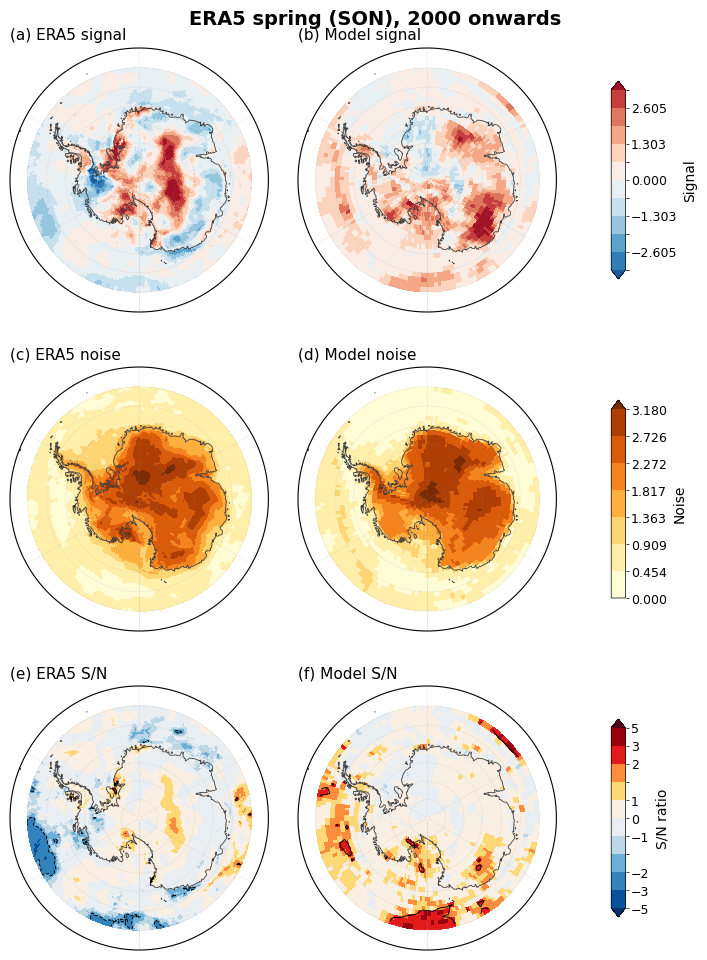

In [104]:
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.path as mpath


def truncate_cmap(name, lo=0.0, hi=1.0, n=256):
    base = mpl.colormaps[name]
    return mcolors.LinearSegmentedColormap.from_list(
        f'{name}_{lo}_{hi}', base(np.linspace(lo, hi, n)))


SIG_CMAP = truncate_cmap('RdBu_r', 0.08, 0.92)
NOISE_CMAP = truncate_cmap('YlOrBr', 0.05, 0.95)

SN_LEVELS = [-5, -3, -2, -1.5, -1, 0, 1, 1.5, 2, 3, 5]
SN_TICKS = [-5, -3, -2, -1, 0, 1, 2, 3, 5]
SN_CMAP = mcolors.ListedColormap(
    ['#08519c', '#3182bd', '#6baed6', '#bdd7e7',
     '#e8eef2', '#f9efe2',
     '#fed976', '#fd8d3c', '#e31a1c', '#99000d'])
SN_CMAP.set_under('#08306b')
SN_CMAP.set_over('#54001a')
SN_NORM = mcolors.BoundaryNorm(SN_LEVELS, SN_CMAP.N)

UNIVERSAL_PLOT_KWARGS = dict(transform=ccrs.PlateCarree(), add_labels=False,
                             add_colorbar=False)

# --- fields ---
sig = {'ERA5': era5_lowss_anom.isel(time=-1), 'Model': hist_lowss_anom.isel(time=-1)}
noise = {'ERA5': era5_noise, 'Model': hist_noise}
sn = {'ERA5': era5_sn.isel(time=-1), 'Model': hist_sn.isel(time=-1)}

# shared limits so the two columns are on the same scale
sig_vmax = float(np.nanpercentile(
    np.abs(np.concatenate([d.values.ravel() for d in sig.values()])), 98))
noise_vmax = float(np.nanpercentile(
    np.concatenate([d.values.ravel() for d in noise.values()]), 98))

SIG_LEVELS = np.linspace(-sig_vmax, sig_vmax, 11)
NOISE_LEVELS = np.linspace(0, noise_vmax, 8)

# --- figure and axes (explicit positions, figure coordinates) ---
fig = plt.figure(figsize=(8, 11))

MAP_W = 0.33
MAP_H = MAP_W * 8 / 11   # square in inches

COL_X = {'ERA5': 0.04, 'Model': 0.40}
ROW_Y = {'sig': 0.680, 'noise': 0.390, 'sn': 0.100}
CBAR_X, CBAR_W = 0.795, 0.018

axes = {(row, col): fig.add_axes([COL_X[col], ROW_Y[row], MAP_W, MAP_H],
                                 projection=ccrs.SouthPolarStereo())
        for row in ROW_Y for col in COL_X}

caxes = {row: fig.add_axes([CBAR_X, ROW_Y[row] + 0.03, CBAR_W, MAP_H - 0.06])
         for row in ROW_Y}

# --- data ---
for col in COL_X:
    p_sig = sig[col].plot(ax=axes[('sig', col)], levels=SIG_LEVELS, cmap=SIG_CMAP,
                          extend='both', **UNIVERSAL_PLOT_KWARGS)
    p_noise = noise[col].plot(ax=axes[('noise', col)], levels=NOISE_LEVELS,
                              cmap=NOISE_CMAP, extend='max', **UNIVERSAL_PLOT_KWARGS)
    p_sn = sn[col].plot(ax=axes[('sn', col)], cmap=SN_CMAP, norm=SN_NORM,
                        **UNIVERSAL_PLOT_KWARGS)
    sn[col].plot.contour(ax=axes[('sn', col)], levels=[-2, 2], colors='k',
                         linewidths=0.7, add_labels=False,
                         transform=ccrs.PlateCarree())

# --- colorbars (one per row, shared across columns) ---
cb_sig = fig.colorbar(p_sig, cax=caxes['sig'], label='Signal')
cb_noise = fig.colorbar(p_noise, cax=caxes['noise'], label='Noise')
cb_sn = fig.colorbar(p_sn, cax=caxes['sn'], label='S/N ratio',
                     extend='both', ticks=SN_TICKS, spacing='uniform')

for cb in (cb_sig, cb_noise, cb_sn):
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=9, length=2, width=0.5, pad=2)
    cb.ax.yaxis.label.set_size(10)

cb_sn.dividers.set_color('white')
cb_sn.dividers.set_linewidth(0.8)

# --- map furniture ---
theta = np.linspace(0, 2 * np.pi, 200)
circle = mpath.Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)

for ax in axes.values():
    ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines(linewidth=0.6, color='0.25')
    ax.gridlines(linewidth=0.4, color='0.6', alpha=0.5, linestyle=':')

PANEL_LABELS = {('sig', 'ERA5'): '(a) ERA5 signal',
                ('sig', 'Model'): '(b) Model signal',
                ('noise', 'ERA5'): '(c) ERA5 noise',
                ('noise', 'Model'): '(d) Model noise',
                ('sn', 'ERA5'): '(e) ERA5 S/N',
                ('sn', 'Model'): '(f) Model S/N'}

for key, label in PANEL_LABELS.items():
    axes[key].set_title(label, loc='left', fontsize=11)

fig.suptitle('ERA5 spring (SON), 2000 onwards', fontsize=14, fontweight='bold', y=0.955)

Text(0.5, 1.0, 'ERA5')

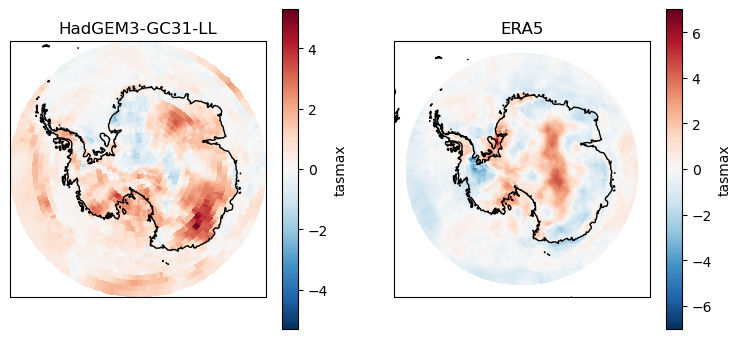

In [98]:
# --- figure and axes (explicit positions, figure coordinates) ---
fig = plt.figure(figsize=(8, 9.5))

MAP_W = 0.40
MAP_H = MAP_W * 8 / 9.5   # square in inches

ax_a = fig.add_axes([0.06, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())
ax_b = fig.add_axes([0.54, 0.585, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())

hist_lowss_anom.isel(time=-1).plot(ax=ax_a, transform=ccrs.PlateCarree())
era5_lowss_anom.isel(time=-1).plot(ax=ax_b, transform=ccrs.PlateCarree())

axes = [ax_a, ax_b]

for ax in axes:
    ax.coastlines()


ax_a.set_title(model)
ax_b.set_title('ERA5')

# ax_c = fig.add_axes([0.30, 0.115, MAP_W, MAP_H], projection=ccrs.SouthPolarStereo())

# cax_a = fig.add_axes([0.10, 0.545, 0.32, 0.016])
# cax_b = fig.add_axes([0.58, 0.545, 0.32, 0.016])
# cax_c = fig.add_axes([0.28, 0.075, 0.44, 0.018])

### Trends

In [ ]:
hist_summer_ds = hist_seasonal_ds#.sel(time=hist_seasonal_ds['time.month']==6)

In [ ]:
hist_summer_2000_ds = hist_summer_ds.sel(time=hist_summer_ds['time.year']>2000)

In [ ]:
hist_summer_2000_trends_ds = grid_slope(hist_summer_2000_ds).compute()

In [ ]:
hist_summer_2000_sig_ds = grid_mk(hist_summer_2000_ds).compute()

In [ ]:
sig

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

trend = (hist_summer_2000_trends_ds.squeeze(drop=True) * 10).compute()
sig = hist_summer_2000_sig_ds.squeeze(drop=True).compute().sig
m = sig.values.astype(bool)

fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='0.3')
ax.gridlines(linestyle=':', alpha=0.5, color='grey')

vmax = float(abs(trend).quantile(0.98))
im = trend.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    add_colorbar=False,
)

lon2d, lat2d = np.meshgrid(trend.lon.values, trend.lat.values)
ax.scatter(lon2d[m], lat2d[m], s=0.6, c='k', alpha=0.5,
           transform=ccrs.PlateCarree(), rasterized=True)

cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.78, pad=0.06)
cb.ax.tick_params(labelsize=8, length=2)
cb.set_label('TXx trend (K decade$^{-1}$)', fontsize=10)
ax.set_title('DJF TXx trend, 2001–2014 (stipple: p < 0.05)', fontsize=11)

# PR

In [ ]:
import numpy as np


def sorted_percentile(sorted_vals, percentile, n_valid=None):
    """Extract a percentile from a pre-sorted 1D array. O(1).

    Linear interpolation between order statistics, matching np.percentile's
    default (method='linear').

    sorted_vals: sorted ascending, NaNs at the end.
    percentile: in [0, 100].
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if np.all(np.isnan(sorted_vals)): return np.nan
        
    if n_valid is None:
        n_valid = len(sorted_vals)
    if n_valid == 0:
        return np.nan

    # Fractional index into the valid block: 0 -> index 0, 100 -> n_valid-1.
    pos = (n_valid - 1) * percentile / 100.0
    below = int(np.floor(pos))
    above = min(below + 1, n_valid - 1)  # clip so 100 doesn't run past the end

    return sorted_vals[below] + (pos - below) * (
        sorted_vals[above] - sorted_vals[below]
    )

In [ ]:
q = 99

In [ ]:
nat_sorted = xr.apply_ufunc(
    np.sort, hist_nat_ds,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    output_dtypes=[np.float32],
)

In [ ]:
nat_q = xr.apply_ufunc(
    sorted_percentile, nat_sorted, q,
    input_core_dims=[['time'], []],
    dask='parallelized',
    vectorize=True,
    output_dtypes=[np.float32],
).persist()

In [ ]:
window = 30# * 365

In [ ]:
from dask.distributed import wait

In [ ]:
exceed = (hist_ds > nat_q).persist()
counts_annual = exceed.resample(time='YE').sum().persist()
counts = counts_annual.rolling(time=window).sum().persist()
wait(counts);


p_hist = counts / (window *365)
p_nat = (100 - q) / 100
pr = (p_hist / p_nat)

In [88]:
pr = pr.where(landsea_mask_ds)

In [89]:
# p_hist = counts / window
# p_nat = (100 - q) / 100
# pr = (p_hist / p_nat)

In [90]:
pr = pr.compute()

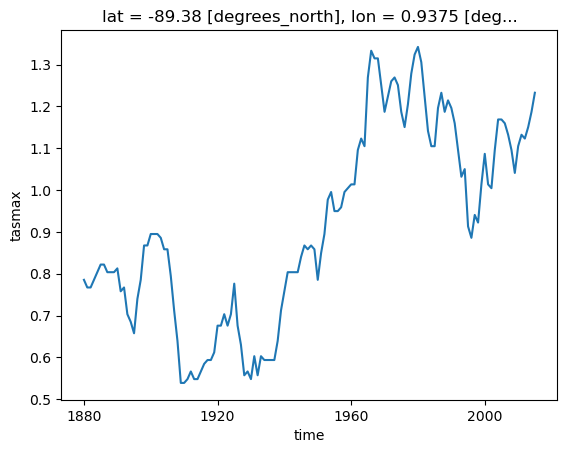

In [91]:
pr.isel(lat=0, lon=0).plot()

In [92]:
qs = pr.quantile([0.0, 0.01, 0.25, 0.5, 0.75, 0.99, 1.0], dim=['lat', 'lon'])

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Text(0.5, 1.0, 'Spatial spread of PR across Antarctic gridpoints, 99th percentile TXx')

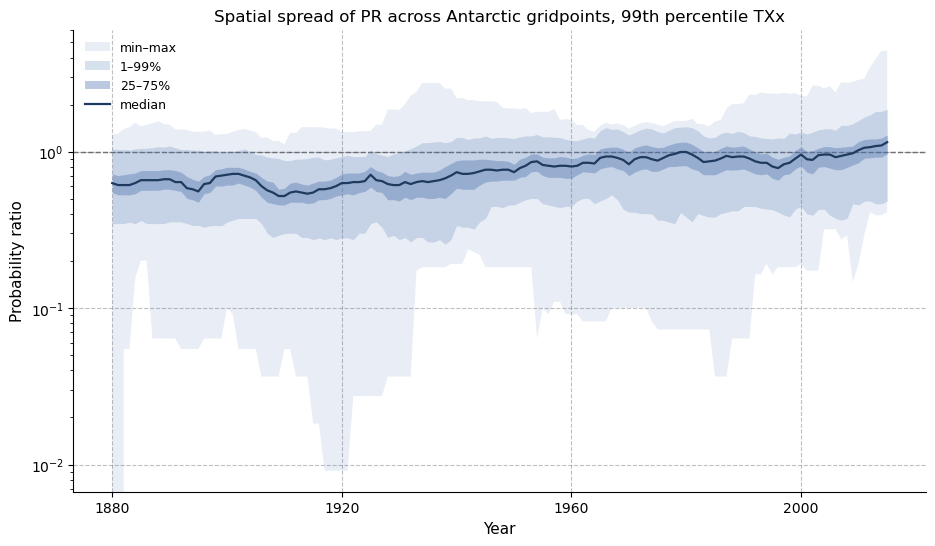

In [93]:
import matplotlib.pyplot as plt
import numpy as np

qs = pr.quantile([0.0, 0.01, 0.25, 0.5, 0.75, 0.99, 1.0], dim=['lat', 'lon'])

fig, ax = plt.subplots(figsize=(11, 6))
ax.axhline(1.0, color='0.4', lw=1.0, ls='--', zorder=1)

ax.fill_between(pr.time.values, qs.sel(quantile=0.0), qs.sel(quantile=1.0),
                color='#4C72B0', alpha=0.12, lw=0, label='min–max', zorder=2)
ax.fill_between(pr.time.values, qs.sel(quantile=0.01), qs.sel(quantile=0.99),
                color='#4C72B0', alpha=0.22, lw=0, label='1–99%', zorder=3)
ax.fill_between(pr.time.values, qs.sel(quantile=0.25), qs.sel(quantile=0.75),
                color='#4C72B0', alpha=0.38, lw=0, label='25–75%', zorder=4)
ax.plot(pr.time, qs.sel(quantile=0.5), lw=1.6, color='#1F3A5F',
        label='median', zorder=5)

ax.set_yscale('log')
ax.set_ylabel('Probability ratio', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5, color='grey')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.set_title(f'Spatial spread of PR across Antarctic gridpoints, {q}th percentile TXx',
             fontsize=12)

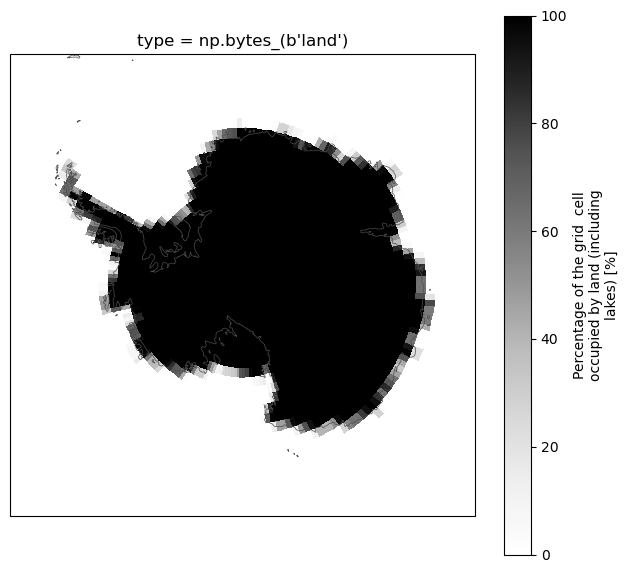

In [106]:
fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

landsea_mask_ds.sel(lat=slice(-90, -60)).plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='Greys'
)
ax.coastlines(linewidth=0.5, color='0.3')

In [101]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, from_levels_and_colors

ratios = np.array([1.2, 1.4, 1.6, 1.8, 2, 2.5, 3, 4, 5])
levels = np.concatenate([1 / ratios[::-1], [1.0], ratios])

n_neg = int((levels < 1).sum())
n_pos = int((levels > 1).sum())

warm_cmap = plt.get_cmap('inferno_r')          # pale yellow -> orange -> red -> purple
cool_cmap = LinearSegmentedColormap.from_list('pr_cool', [
    '#eafaff', '#a9e0f2', '#5cbcdb', '#2b8cbe', '#225ea8', '#253494', '#101a4d',
])

warm = warm_cmap(np.linspace(0.00, 0.80, n_pos))
cool = cool_cmap(np.linspace(0.03, 0.86, n_neg))[::-1]

colors = np.vstack([cool_cmap(0.97), cool, warm, warm_cmap(0.90)])
cmap, norm = from_levels_and_colors(levels, colors, extend='both')

Text(0.5, 1.0, 'PR, 99th percentile TXx — final 30-yr window')

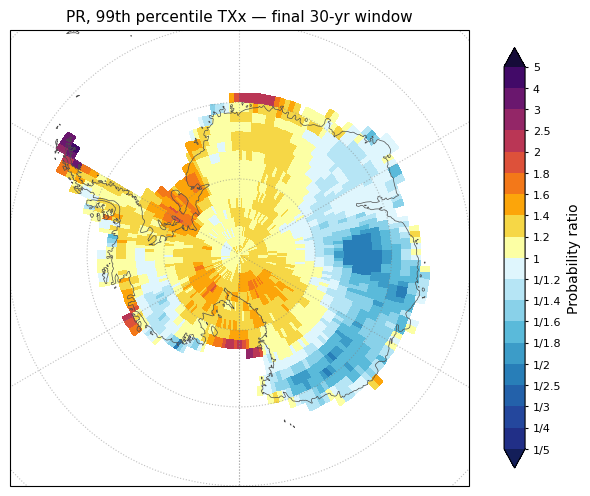

In [102]:
def ratio_label(v):
    if np.isclose(v, 1.0):
        return '1'
    return f'{v:g}' if v > 1 else f'1/{1 / v:g}'

pr_final = pr.isel(time=-1)

fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='0.3')
ax.gridlines(linestyle=':', alpha=0.5, color='grey')

im = pr_final.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap=cmap, norm=norm,
    add_colorbar=False,
)

cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.78, pad=0.06)
cb.set_ticks(levels, labels=[ratio_label(v) for v in levels])
cb.ax.tick_params(labelsize=8, length=2)
cb.set_label('Probability ratio', fontsize=10)

ax.set_title(f'PR, {q}th percentile TXx — final {window}-yr window', fontsize=11)

# Trends

# Old

In [47]:
# epochs = {}
# for end in range(window, hist_ds.sizes['time'], 365):
#     sub = exceed.isel(time=slice(end-window, end))
#     epochs[hist_ds.time.values[end-1]] = sub.sum('time')

# pr_epochs = xr.concat(list(epochs.values()), dim='time') / window / ((100 - q) / 100)

In [69]:
pr_epochs = pr_epochs.compute()

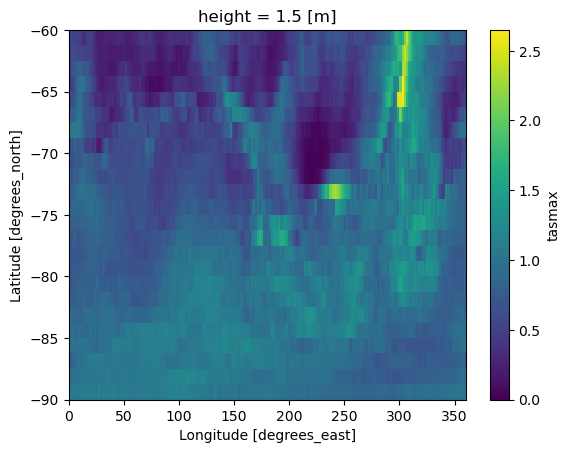

In [70]:
pr_epochs.isel(time=-1).plot()

# Percentiles - draft array

In [33]:
# hist_nat_da = xr.open_mfdataset(hist_nat_path)
# hist_nat_da.tasmax

In [34]:
# hist_da.tasmax.encoding['chunksizes']

In [31]:
#hist_da = xr.open_dataset(hist_path)

In [26]:
import matplotlib.pyplot as plt

In [27]:
loc = dict(lat=-62, lon=57, method='nearest')

In [193]:
arr = hist_da.tasmax.sel(**loc).values

In [194]:
arr_nat = hist_nat_da.tasmax.sel(**loc).values

In [195]:
hist_nat_time = hist_nat_da.time.values
hist_time = hist_da.time.values

In [196]:
hist_nat_da

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 36000, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 288kB 1850-01-01 12:00:00 ... 1949-12-30 12:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 576kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    tasmax     (time, lat, lon) float32 4GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            DAMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  154800.0
    creation_date:          2021-12-21T14:13:06Z
    ...                     ...
    tracking_id:            hdl:21.14100/3e826075-70b4-4f00-a72f-e79b63e042a0
    variable_id:            tasmax
    variable_name:          tasmax
    variant_label:          r10i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.6.1

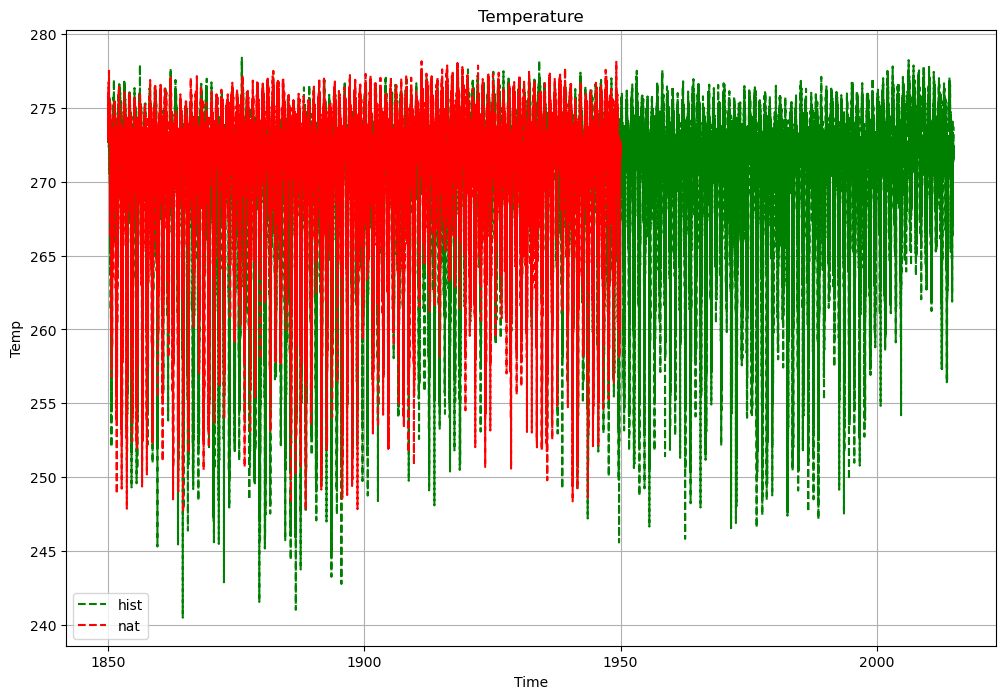

In [197]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
ax.plot(hist_time, arr, linestyle='--', color='green', label='hist')
ax.plot(hist_nat_time, arr_nat, linestyle='--', color='red', label='nat')

ax.set_ylabel('Temp')
ax.set_xlabel('Time')
ax.grid()
ax.set_title('Temperature')
ax.legend()


In [199]:
def exceedances(sorted_vals, threshold, n_valid=None):
    """Values strictly above a threshold, from pre-sorted data.

    sorted_vals: sorted ascending, NaNs at the end.
    threshold: exceedances are strictly greater than this.
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if n_valid is None:
        n_valid = len(sorted_vals)

    # Binary search for first index above threshold. Slicing to n_valid
    # excludes NaNs, which sort as greater than everything.
    start = np.searchsorted(sorted_vals[:n_valid], threshold, side='right')
    return sorted_vals[start:n_valid]

In [200]:
def threshold_exceedances_sorted(sorted_vals, threshold, n_valid=None):
    """Values strictly above a threshold, from pre-sorted data.

    sorted_vals: sorted ascending, NaNs at the end.
    threshold: exceedances are strictly greater than this.
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if n_valid is None:
        n_valid = len(sorted_vals)

    # Binary search for first index above threshold. Slicing to n_valid
    # excludes NaNs, which sort as greater than everything.
    start = np.searchsorted(sorted_vals[:n_valid], threshold, side='right')
    return sorted_vals[start:n_valid]

# Probability Ratio

$PR = \dfrac{P_{hist}}{P_{hist nat}}$

In [201]:
q = 99

In [202]:
arr_sorted = np.sort(arr)
arr_nat_sorted = np.sort(arr_nat)

In [203]:
arr_counts = len(arr_sorted)

In [204]:
nat_q_float = sorted_percentile(arr_nat_sorted, q)
nat_q_float

np.float32(276.3362)

In [205]:
hist_q_exceedances = threshold_exceedances_sorted(arr_sorted, nat_q_float)

In [206]:
len(hist_q_exceedances)/len(arr_sorted)

0.005303030303030303

In [207]:
window = 30 * 365
window_counts = []
for i in range(len(arr_sorted)-window):
    sub_arr = arr[i:i+window]
    counts = np.count_nonzero(sub_arr > nat_q_float)
    window_counts.append(counts)

window_counts = np.array(window_counts)

In [208]:
p_hist = window_counts/window
p_hist

array([0.00255708, 0.00255708, 0.00255708, ..., 0.01214612, 0.01214612,
       0.01214612], shape=(48450,))

In [209]:
p_nat = (100 - q)/100

In [210]:
pr_arr = p_hist/p_nat

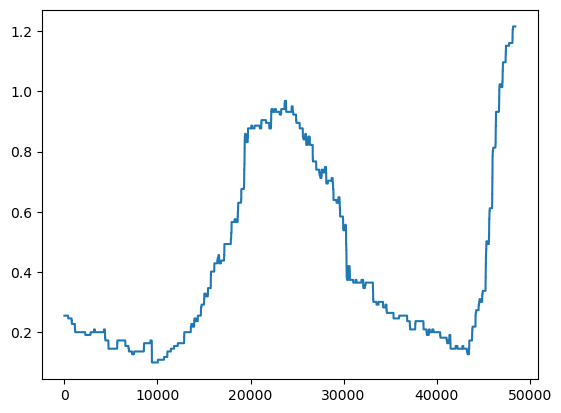

In [211]:
plt.plot(pr_arr)

In [212]:
len(pr_arr)

48450

In [236]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

Text(0.5, 0.96, "Probability ratio at {'lat': -62, 'lon': 57, 'method': 'nearest'}")

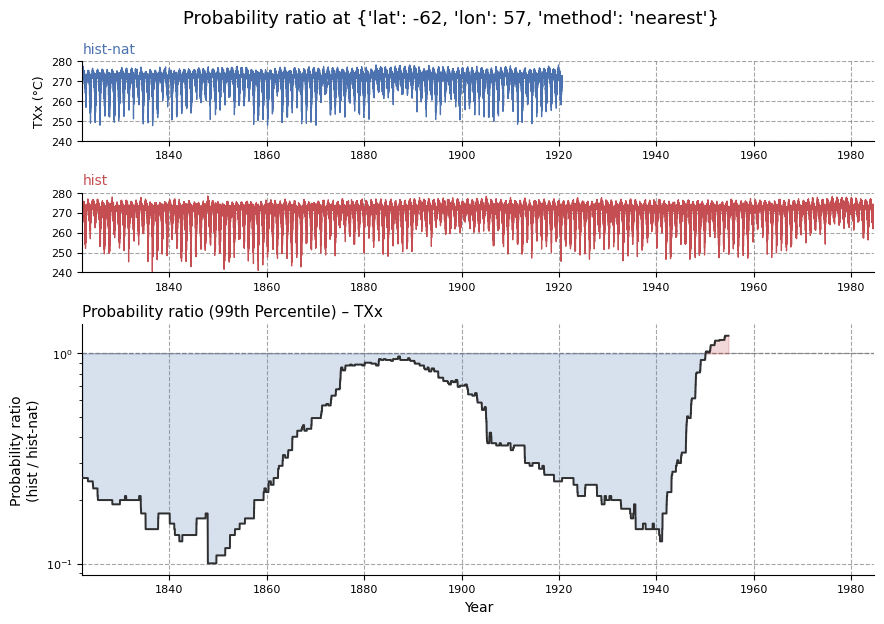

In [240]:


C_NAT, C_HIST, C_PR = "#4C72B0", "#C44E52", "#2F2F2F"

t = np.asarray(hist_time)
xlim = (t.min(), t.max())

fig = plt.figure(figsize=(9, 6.5))
gs = GridSpec(3, 1, figure=fig, height_ratios=[0.7, 0.7, 2.2],
              hspace=0.38, left=0.09, right=0.97, top=0.88, bottom=0.09)

ax_nat  = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1])
ax_pr   = fig.add_subplot(gs[2])

ax_nat.plot(hist_nat_time, arr_nat, lw=0.9, color=C_NAT)
ax_nat.set_title("hist-nat", fontsize=10, loc="left", color=C_NAT)
ax_nat.set_ylabel("TXx (°C)", fontsize=9)

ax_hist.plot(hist_time, arr, lw=0.9, color=C_HIST)
ax_hist.set_title("hist", fontsize=10, loc="left", color=C_HIST)

ax_pr.axhline(1.0, color="0.55", lw=0.9, ls="--", zorder=1)
pr_time = hist_time[:len(pr_arr)]
ax_pr.plot(pr_time, pr_arr, lw=1.4, color=C_PR, zorder=3)
ax_pr.fill_between(pr_time, 1.0, pr_arr, where=np.asarray(pr_arr) >= 1.0,
                   color=C_HIST, alpha=0.22, interpolate=True, zorder=2)
ax_pr.fill_between(pr_time, 1.0, pr_arr, where=np.asarray(pr_arr) < 1.0,
                   color=C_NAT, alpha=0.22, interpolate=True, zorder=2)
ax_pr.set_yscale("log")
ax_pr.set_ylabel("Probability ratio\n(hist / hist-nat)", fontsize=10)
ax_pr.set_xlabel("Year", fontsize=10)
ax_pr.set_title(f"Probability ratio ({q}th Percentile) – TXx", fontsize=11, loc="left")

for ax in (ax_nat, ax_hist):
    ax.set_ylim(240, 280)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
for ax in (ax_nat, ax_hist, ax_pr):
    ax.set_xlim(xlim)
    ax.grid(True, linestyle='--', alpha=0.7, color='grey')
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    # if np.issubdtype(t.dtype, np.datetime64):
    ax.xaxis.set_major_locator(mdates.YearLocator(20))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        

fig.suptitle(f"Probability ratio at {loc}", fontsize=13, y=0.96)